# 시계열 데이터 분석

## 1. 분석 주제

서울시의 일일 기온 데이터(1907~2026)를 시각화하고 분석하여, **서울의 여름철 기온이 실제로 상승했는지, 35°C 이상인 날이 증가하고 있는지**를 확인한다. 또한 과거 기온 데이터를 기반으로 **향후 5년간 서울의 여름철 기온을 예측**한다.

## 2. 분석 질문

1. **향후 5년간 여름철 기온 예측**

   * 과거 기온 데이터를 기반으로 향후 5년간 서울의 여름철 평균 기온을 예측한다.

2. **35°C 초과 일수 및 전반적인 온난화 추세 분석**

   * 연도별로 일 최고기온이 35°C를 초과한 날의 수를 산출하고, 해당 일수가 장기적으로 증가하는 추세인지 분석한다.

3. **계절별 기온 추세 분석 (여름 vs. 겨울)**

   * 서울의 평균 여름철/겨울철 기온이 장기적으로 상승/하락하고 있는지 분석한다.

4. **여름과 겨울이 확장되고 있는지 분석**

   * 일평균기온을 다음과 같은 구간으로 분류한다: summer_like, winter_like, warm_day, hot_day, extreme_heat_day, cold_day.
   * 연도별로 각 기온 구간에 해당하는 일수를 산출하고, 과거와 비교하여 각 구간의 일수가 어떻게 변화했는지 분석한다.
   * 특히 **여름철 및 겨울철로 볼 수 있는 기온 구간에 해당하는 날의 수가 증가하고 있는지**를 확인하여 계절별 기온 변화 양상을 분석한다.

In [8]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

print(pd.__version__)

3.0.5


## 3. 데이터 로드

In [15]:
filepath = "../data/raw/dataset_original.csv"
df = pd.read_csv(filepath)

In [16]:
df.head(10)

,station_ID,location,date,tavg,tmin,tmax
0,108,seoul,01/10/1907,13.5,7.9,20.7
1,108,seoul,02/10/1907,16.2,7.9,22.0
2,108,seoul,03/10/1907,16.2,13.1,21.3
3,108,seoul,04/10/1907,16.5,11.2,22.0
4,108,seoul,05/10/1907,17.6,10.9,25.4
5,108,seoul,06/10/1907,13.0,11.2,21.3
6,108,seoul,07/10/1907,11.3,6.3,16.1
7,108,seoul,08/10/1907,8.9,3.9,14.9
8,108,seoul,09/10/1907,11.6,3.8,21.1
9,108,seoul,10/10/1907,14.2,6.4,24.1


## 4. 데이터 기본 정보 확인

In [ ]:
df.shape # data size

(42236, 6)

In [ ]:
df.columns

Index(['station_ID', 'location', 'date', 'tavg', 'tmin', 'tmax'], dtype='str')

In [ ]:
df.info() # data type or df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 42236 entries, 0 to 42235
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_ID  42236 non-null  int64  
 1   location    42236 non-null  str    
 2   date        42236 non-null  str    
 3   tavg        42236 non-null  float64
 4   tmin        42234 non-null  float64
 5   tmax        42234 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 1.9 MB


In [ ]:
df.describe() # 통계 정보 stat info

,station_ID,tavg,tmin,tmax
count,42236.0,42236.000000,42234.000000,42234.000000
mean,108.0,11.856317,7.573957,16.850983
std,0.0,10.674639,10.905265,10.979455
min,108.0,-19.200000,-23.100000,-16.300000
25%,108.0,2.800000,-1.300000,7.400000
50%,108.0,13.100000,8.200000,18.700000
75%,108.0,21.300000,17.200000,26.300000
max,108.0,33.700000,30.300000,39.600000


In [ ]:
df.isnull().sum()   # 결측치; missing value
                    # tmin와 tmax에 결측치 두 개씩 있음을 확인

station_ID    0
location      0
date          0
tavg          0
tmin          2
tmax          2
dtype: int64

In [ ]:
df.duplicated().sum()   # 중복 데이터 없음

np.int64(0)

## 5. 데이터 클리닝 (Data Cleaning)

* 결측치 Missing values
* 중복 데이터 행 Duplicate rows
* 중복 날짜 Duplicate dates
* 날짜 검사 / 날짜 형식 변환 Date validation/conversion
* 이상치 탐지 Outlier detection

### 5.1. 결측치 (Missing values)

In [ ]:
print("-" * 20)
print("변수당 결측치 개수")
print("-" * 20)
print(df.isnull().sum())    # 결측치 몇 개있는지 확인
print("-" * 20)
print("결측치 위치")
print("-" * 20)
print(df[df["tmin"].isnull() | df["tmax"].isnull()])    # tmax와 tmin에 결측치 있다고 나왔으므로 이 두 변수만 확인

--------------------
변수당 결측치 개수
--------------------
station_ID    0
location      0
date          0
tavg          0
tmin          2
tmax          2
dtype: int64
--------------------
결측치 위치
--------------------
       station_ID location        date  tavg  tmin  tmax
20504         108    seoul  19/02/1967  -1.7   NaN   NaN
39002         108    seoul  12/10/2017  11.4   8.8   NaN
40763         108    seoul  08/08/2022  26.8   NaN  28.4


* 결측치 있음을 확인하였고 NaN로 놔두기로 결정. 결측치를 임의의 값으로 채우면 실제 관측되지 않은 기온을 만들어내어 장기적인 기온 추세와 분석 결과를 왜곡할 수 있기 때문.

### 5.2. 중복 데이터 (Duplicates)

In [ ]:
print("Duplicate rows:", df.duplicated().sum())             # 모든 column에 중복 데이터 유무 확인
print("Duplicate dates:", df["date"].duplicated().sum())    # 날짜에 중복 데이터 유무 확인

# duplicate_dates = df[df["date"].duplicated(keep=False)]   # 필요시 사용

Duplicate rows: 0
Duplicate dates: 0


### 5.3. 날짜 처리 (Date handling)

In [ ]:
print(df["date"].dtype)     # 데이터 타입이 str인 것을 확인

str


In [ ]:
# 모든 날짜가 'dd/mm/yyyy' 를 따르는지 확인: 0을 반환하면 모든 날짜는 dd/mm/yyyy 형식을 따른다고 해석 가능.

date_check = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y",
    errors="coerce"
)
print("Invalid date values:", date_check.isna().sum())

Invalid date values: 0


In [27]:
# 필요한 경우 아래 실행
print(df.loc[date_check.isna(), "date"])

Series([], Name: date, dtype: str)


In [29]:
# 변환

df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y"
)

In [30]:
print(df["date"].dtype)

datetime64[us]


In [31]:
# Check the date range
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 1907-10-01 00:00:00
End date: 2026-08-19 00:00:00


In [ ]:
# Check whether the dates are sorted:
print("Dates sorted:", df["date"].is_monotonic_increasing)

# If not sorted, use:
# df = df.sort_values("date").reset_index(drop=True)

Dates sorted: True


필요할 경우 실행:

```python
df = df.sort_values("date").reset_index(drop=True)
```

### 5.4. 이상치 탐지 (Outlier Detection)

* Detect → Investigate → Decide 따름
* 여기서는 만약 60나 -50도가 나온다면 관측이 잘못된 값이라고 여겨져서 제거하겠지만, IQR방법을 사용했을 경우 한국에서 45도까지는 이상치의 범위에 들어가더라도 제거하지 않을 것 (실제 극한 기상 현상이고 오류가 아니기에).

#### (1) 산점도 (Scatter plot) 

* extrem values를 시각적으로 볼 수는 있지만, 시각적 검사만으로는 이상치를 탐지하기에 충분하지 않았음.

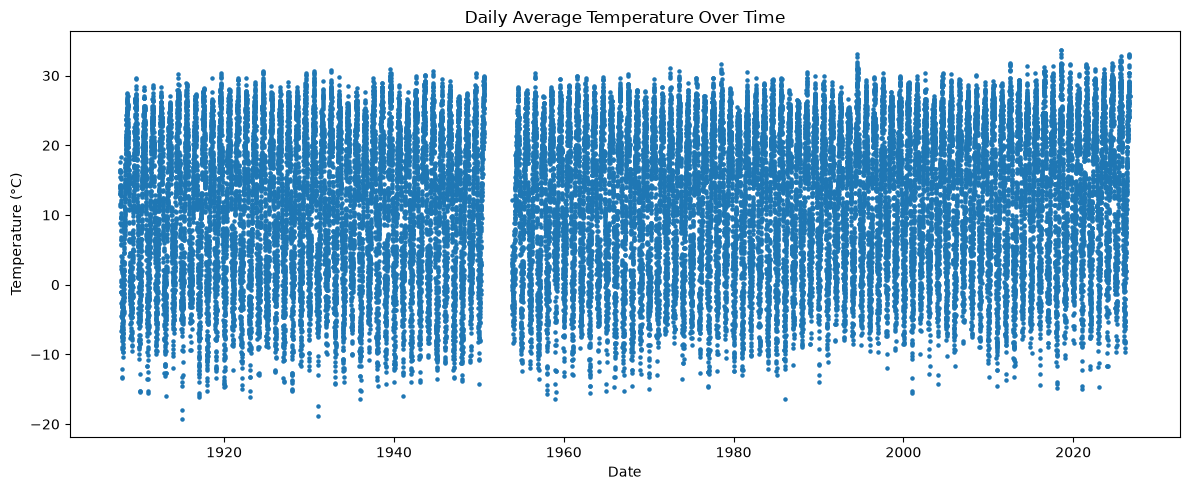

In [ ]:
# Daily Average Temperature Over Time

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.scatter(df["date"], df["tavg"], s=5, label="Average Temperature")
plt.title("Daily Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

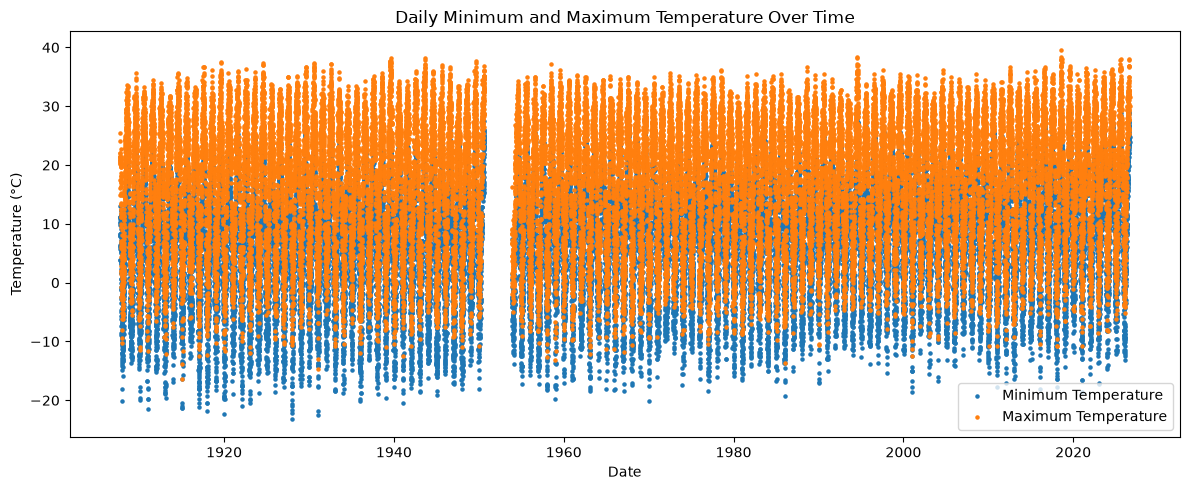

In [ ]:
# Daily Minimum and Maximum Temperature Over Time

plt.figure(figsize=(12, 5))

plt.scatter(df["date"], df["tmin"], s=5, label="Minimum Temperature")
plt.scatter(df["date"], df["tmax"], s=5, label="Maximum Temperature")

plt.title("Daily Minimum and Maximum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.tight_layout()
plt.show()

#### (2) 사분위 범위 Interquartile Range (IQR)

* 통계적으로 unusual values를 식별.

In [ ]:
def find_iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)  # Finds the number where 25% of the data points are <= that value.
    q3 = df[column].quantile(0.75)  # Finds the number where 75% of the data points are <= that value.

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\n{column}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    return outliers


tavg_outliers = find_iqr_outliers(df, "tavg")
tmin_outliers = find_iqr_outliers(df, "tmin")
tmax_outliers = find_iqr_outliers(df, "tmax")

# 이상치 없음을 확인


tavg
Q1: 2.80
Q3: 21.30
IQR: 18.50
Lower bound: -24.95
Upper bound: 49.05
Number of outliers: 0

tmin
Q1: -1.30
Q3: 17.20
IQR: 18.50
Lower bound: -29.05
Upper bound: 44.95
Number of outliers: 0

tmax
Q1: 7.40
Q3: 26.30
IQR: 18.90
Lower bound: -20.95
Upper bound: 54.65
Number of outliers: 0


In [ ]:
# 위에서 이미 이상치 없음을 확인하였지만 있다면 아래 실행하여 확인

print(tavg_outliers[["date", "tavg"]])
print(tmin_outliers[["date", "tmin"]])
print(tmax_outliers[["date", "tmax"]])

Empty DataFrame
Columns: [date, tavg]
Index: []
Empty DataFrame
Columns: [date, tmin]
Index: []
Empty DataFrame
Columns: [date, tmax]
Index: []


### 5.7. 필요없는 columns 제거

In [ ]:
# 108과 seoul만 있음을 확인:
print(df["station_ID"].unique())
print(df["location"].unique())

[108]
<StringArray>
['seoul']
Length: 1, dtype: str


In [46]:
df = df.drop(columns=["station_ID", "location"])
print(df.columns)

Index(['date', 'tavg', 'tmin', 'tmax'], dtype='str')


### 5.8. Cleaning 요약

날짜만 변환함.

In [47]:
print("\n=== Data Cleaning Summary ===")

print("Number of rows:", len(df))
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df["date"].duplicated().sum())

print("\nDate range:")
print(df["date"].min(), "~", df["date"].max())


=== Data Cleaning Summary ===
Number of rows: 42236
Missing values:
date    0
tavg    0
tmin    2
tmax    2
dtype: int64

Duplicate rows: 0
Duplicate dates: 0

Date range:
1907-10-01 00:00:00 ~ 2026-08-19 00:00:00


## 6. 데이터 변환 (Data Transformation)

### 6.1. 현재 데이터셋 확인

In [44]:
print(df.head())
print("-" * 20)
print(df.dtypes)

   station_ID location       date  tavg  tmin  tmax
0         108    seoul 1907-10-01  13.5   7.9  20.7
1         108    seoul 1907-10-02  16.2   7.9  22.0
2         108    seoul 1907-10-03  16.2  13.1  21.3
3         108    seoul 1907-10-04  16.5  11.2  22.0
4         108    seoul 1907-10-05  17.6  10.9  25.4
--------------------
station_ID             int64
location                 str
date          datetime64[us]
tavg                 float64
tmin                 float64
tmax                 float64
dtype: object


### 6.2. year, month, day, day_of_year 생성

In [ ]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear     # Jan 1 → 1; Jan 2 → 2; Feb 1 → 32

print(df.head())

        date  tavg  tmin  tmax  year  month  day  day_of_year
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278


In [50]:
df.dtypes

date           datetime64[us]
tavg                  float64
tmin                  float64
tmax                  float64
year                    int32
month                   int32
day                     int32
day_of_year             int32
dtype: object

### 6.3. season 생성

* Spring: March–May
* Summer: June–August
* Autumn: September–November
* Winter: December–February

In [51]:
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"

df["season"] = df["month"].apply(get_season)


## or:

# season_map = {
#     1: "Winter",
#     2: "Winter",
#     3: "Spring",
#     4: "Spring",
#     5: "Spring",
#     6: "Summer",
#     7: "Summer",
#     8: "Summer",
#     9: "Autumn",
#     10: "Autumn",
#     11: "Autumn",
#     12: "Winter"
# }

# df["season"] = df["month"].map(season_map)

In [53]:
df[["date", "month", "season"]].head()

,date,month,season
0,1907-10-01,10,Autumn
1,1907-10-02,10,Autumn
2,1907-10-03,10,Autumn
3,1907-10-04,10,Autumn
4,1907-10-05,10,Autumn


### 6.4. 온도 기반 indicator 생성

* 기준은 달라질 수 있음
* 여기서 `summer_like`와 `winter_like` 자체가 "계절이 확장되었다"는 것을 의미하는 것은 아니고 각 날짜가 기온 기준을 만족하는지를 나타내는 indicator임.
    * “5월과 9월이 점점 여름처럼 변하고 있는가?”
    * “11월과 3월이 점점 겨울처럼 변하고 있는가?”
    * 에 대한 문제는 Analysis 단계에서 year + month별 summer_like/winter_like 비율을 계산하고 추세를 분석해서 답하게 된다.

In [54]:
# === Create temperature-based season indicators ===
# Summer-like day:
# KMA seasonal criterion: daily average temperature >= 20°C
df["summer_like"] = (df["tavg"] >= 20).astype(int)

# Winter-like day:
# KMA seasonal criterion: daily average temperature <= 5°C
df["winter_like"] = (df["tavg"] <= 5).astype(int)


# === Create warm/hot/extreme heat indicators ===
# Warm day: 25 <= tmax < 30
df["warm_day"] = ((df["tmax"] >= 25) & (df["tmax"] < 30)).astype(int)

# Hot day: 30 <= tmax < 35
df["hot_day"] = ((df["tmax"] >= 30) & (df["tmax"] < 35)).astype(int)

# Extreme heat day: tmax >= 35
df["over_35"] = (df["tmax"] >= 35).astype(int)


# === Create cold-weather indicator ===
# Cold day:
# tmax <= 10°C AND tmin < 0°C
df["cold_day"] = ((df["tmax"] <= 10) & (df["tmin"] < 0)).astype(int)

참고) 데이터 분석시에 아래 사용해서 여름/겨울 확장하고 있는지 체크:

```python
monthly_season = (
    df.groupby(["year", "month"])
      .agg(
          summer_like_ratio=("summer_like", "mean"),
          winter_like_ratio=("winter_like", "mean")
      )
      .reset_index()
)
```

```text
year   month   summer_like_ratio
1907     5          0.02
1908     5          0.04
...
2024     5          0.61
2025     5          0.65
```

### 6.5. 변환된 데이터 확인

In [55]:
print("\n=== Transformed Data ===")
print(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Columns ===")
print(df.columns.tolist())


=== Transformed Data ===
        date  tavg  tmin  tmax  year  month  day  day_of_year  season  \
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274  Autumn   
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275  Autumn   
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276  Autumn   
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277  Autumn   
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278  Autumn   

   summer_like  winter_like  warm_day  hot_day  over_35  cold_day  
0            0            0         0        0        0         0  
1            0            0         0        0        0         0  
2            0            0         0        0        0         0  
3            0            0         0        0        0         0  
4            0            0         1        0        0         0  

=== Data Types ===
date           datetime64[us]
tavg                  float64
tmin                  float64
tmax             

### 6.6. 데이터 유효성 검사

In [56]:
print("\n=== Seasons ===")
print(df["season"].unique())

print("\n=== Year Range ===")
print(df["year"].min(), "~", df["year"].max())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Temperature Indicator Counts ===")

print("Summer-like days:", df["summer_like"].sum())
print("Winter-like days:", df["winter_like"].sum())
print("Warm days (Tmax >= 25°C):", df["warm_day"].sum())
print("Hot days (Tmax >= 30°C):", df["hot_day"].sum())
print("Extreme heat days (Tmax > 35°C):", df["over_35"].sum())
print("Cold days:", df["cold_day"].sum())


=== Seasons ===
<StringArray>
['Autumn', 'Winter', 'Spring', 'Summer']
Length: 4, dtype: str

=== Year Range ===
1907 ~ 2026

=== Missing Values ===
date           0
tavg           0
tmin           2
tmax           2
year           0
month          0
day            0
day_of_year    0
season         0
summer_like    0
winter_like    0
warm_day       0
hot_day        0
over_35        0
cold_day       0
dtype: int64

=== Temperature Indicator Counts ===
Summer-like days: 12664
Winter-like days: 13042
Warm days (Tmax >= 25°C): 8568
Hot days (Tmax >= 30°C): 4084
Extreme heat days (Tmax > 35°C): 315
Cold days: 11250


### 6.7. 처리된 데이터 저장

In [58]:
df.to_csv(
    "../data/processed/dataset_processed.csv",
    index=False,
    encoding="utf-8-sig"
)